<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [115]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

We will import the following libraries for the lab


In [116]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [117]:
from sklearn.model_selection import StratifiedKFold

In [118]:
from sklearn.metrics import classification_report

This function is to plot the confusion matrix.


In [119]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [120]:
from js import fetch
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp1 = await fetch(URL1)
text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
data = pd.read_csv(text1)

In [121]:
#feature_names
feature_names_data =data.columns
feature_names_data

Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'Class'],
      dtype='object')

In [122]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [123]:
data.tail()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
85,86,2020-09-03,Falcon 9,15400.0,VLEO,KSC LC 39A,True ASDS,2,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,2,B1060,-80.603956,28.608058,1
86,87,2020-10-06,Falcon 9,15400.0,VLEO,KSC LC 39A,True ASDS,3,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,2,B1058,-80.603956,28.608058,1
87,88,2020-10-18,Falcon 9,15400.0,VLEO,KSC LC 39A,True ASDS,6,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,5,B1051,-80.603956,28.608058,1
88,89,2020-10-24,Falcon 9,15400.0,VLEO,CCAFS SLC 40,True ASDS,3,True,True,True,5e9e3033383ecbb9e534e7cc,5.0,2,B1060,-80.577366,28.561857,1
89,90,2020-11-05,Falcon 9,3681.0,MEO,CCAFS SLC 40,True ASDS,1,True,False,True,5e9e3032383ecb6bb234e7ca,5.0,0,B1062,-80.577366,28.561857,1


In [124]:
data['LaunchSite'].value_counts()

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

In [125]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

In [126]:
#feature_names
feature_names_X =X.columns
feature_names_X

Index(['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount',
       'Orbit_ES-L1', 'Orbit_GEO', 'Orbit_GTO', 'Orbit_HEO', 'Orbit_ISS',
       'Orbit_LEO', 'Orbit_MEO', 'Orbit_PO', 'Orbit_SO', 'Orbit_SSO',
       'Orbit_VLEO', 'LaunchSite_CCAFS SLC 40', 'LaunchSite_KSC LC 39A',
       'LaunchSite_VAFB SLC 4E', 'LandingPad_5e9e3032383ecb267a34e7c7',
       'LandingPad_5e9e3032383ecb554034e7c9',
       'LandingPad_5e9e3032383ecb6bb234e7ca',
       'LandingPad_5e9e3032383ecb761634e7cb',
       'LandingPad_5e9e3033383ecbb9e534e7cc', 'Serial_B0003', 'Serial_B0005',
       'Serial_B0007', 'Serial_B1003', 'Serial_B1004', 'Serial_B1005',
       'Serial_B1006', 'Serial_B1007', 'Serial_B1008', 'Serial_B1010',
       'Serial_B1011', 'Serial_B1012', 'Serial_B1013', 'Serial_B1015',
       'Serial_B1016', 'Serial_B1017', 'Serial_B1018', 'Serial_B1019',
       'Serial_B1020', 'Serial_B1021', 'Serial_B1022', 'Serial_B1023',
       'Serial_B1025', 'Serial_B1026', 'Serial_B1028', 'Serial_B102

In [127]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [128]:
Y=pd.Series(data['Class'].to_numpy())

In [129]:
type(Y)

pandas.core.series.Series

In [130]:
Y

0     0
1     0
2     0
3     0
4     0
     ..
85    1
86    1
87    1
88    1
89    1
Length: 90, dtype: int64

## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [131]:
# students get this 
transform = preprocessing.StandardScaler()

In [132]:
X=transform.fit_transform(X)

In [133]:
type(X)

numpy.ndarray

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [134]:
#previous version
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.2, random_state=2)
#Stratify the data
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=2, stratify=Y)

we can see we only have 18 test samples.


In [135]:
Y_test.shape

(18,)

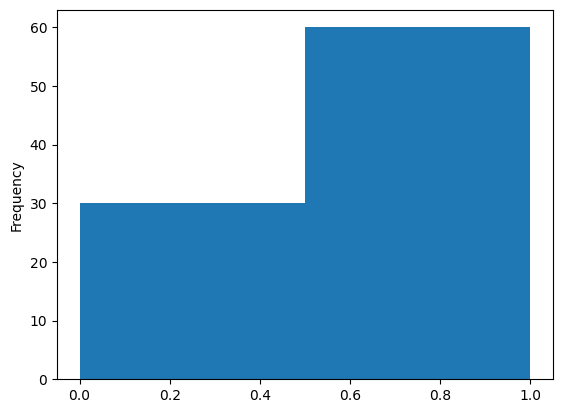

In [136]:
Y.plot(kind='hist', bins=2)
plt.show()

In [137]:
name=[1,0]
values=Y.value_counts()
values

1    60
0    30
Name: count, dtype: int64

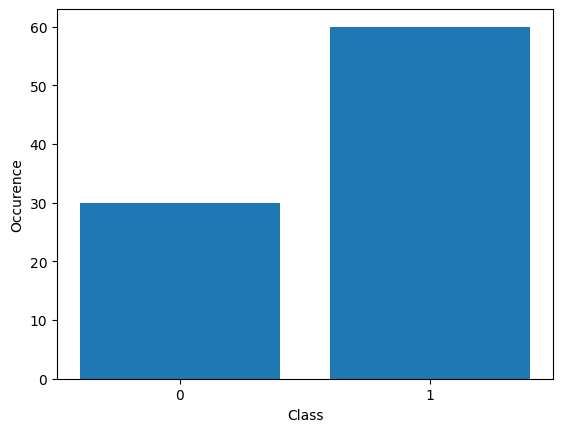

In [138]:
plt.bar(name, list(values[:2]))
plt.xlabel("Class")
plt.ylabel("Occurence")
plt.xticks([0,1])
plt.show()

In [139]:
values_test=Y_test.value_counts()
values_test

1    12
0     6
Name: count, dtype: int64

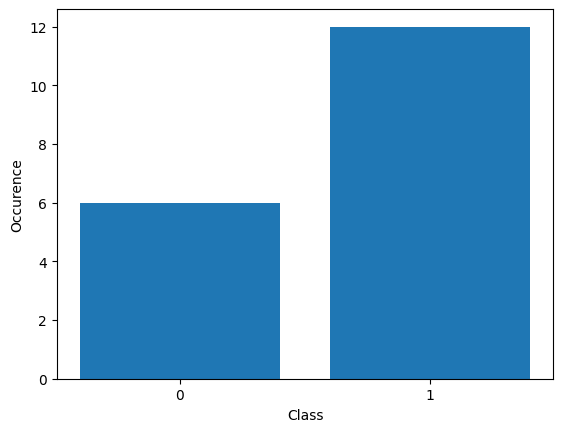

In [140]:
plt.bar(name, list(values_test[:2]))
plt.xlabel("Class")
plt.ylabel("Occurence")
plt.xticks([0,1])
plt.show()

value_Y_train 1    48
0    24
Name: count, dtype: int64


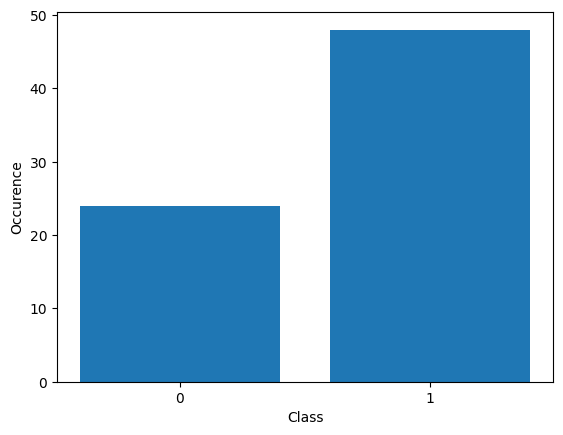

In [141]:
values_train=Y_train.value_counts()
print("value_Y_train", values_train)
plt.bar(name, list(values_train[:2]))
plt.xlabel("Class")
plt.ylabel("Occurence")
plt.xticks([0,1])
plt.show()

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [142]:
#adding the definition of the crossvalidation, to make sure results are reproducible
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=2)

In [143]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [144]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression(random_state=2)


In [145]:
logreg_cv=GridSearchCV(estimator=lr, param_grid=parameters, cv=cv, scoring="accuracy")

In [146]:
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=2, shuffle=True),
             estimator=LogisticRegression(random_state=2),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='accuracy')

In [147]:
best_parameters=logreg_cv.best_params_
best_parameters

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [148]:
print("tuned hyperparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.861111111111111


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [149]:
accuracy_lg_test=logreg_cv.score(X_test, Y_test)
accuracy_lg_test

0.8333333333333334

Lets look at the confusion matrix:


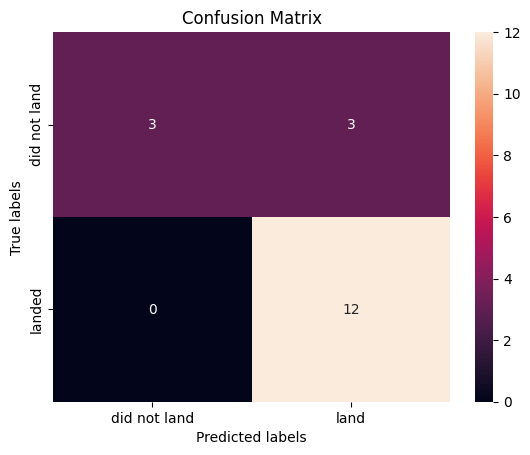

In [150]:
yhat_log=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_log)

In [151]:
#Classification report
report_log=classification_report(Y_test, yhat_log, target_names=["Class 0", "Class 1"])
print(report_log)

              precision    recall  f1-score   support

     Class 0       1.00      0.50      0.67         6
     Class 1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [152]:
parameters = {'kernel':('linear', 'rbf','poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()

In [153]:
#svm_cv=GridSearchCV(estimator=svm, param_grid= parameters)

#changing the GridSearchCV definition
svm_cv = GridSearchCV(
    estimator=svm,
    param_grid=parameters,
    cv=cv,
    scoring="accuracy"
)


In [154]:
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=2, shuffle=True),
             estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'sigmoid')},
             scoring='accuracy')

In [155]:
print("tuned hyperparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 0.03162277660168379, 'gamma': 0.001, 'kernel': 'linear'}
accuracy : 0.861111111111111


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [156]:
accuracy_svm_test=svm_cv.score(X_test, Y_test)
accuracy_svm_test

0.7777777777777778

We can plot the confusion matrix


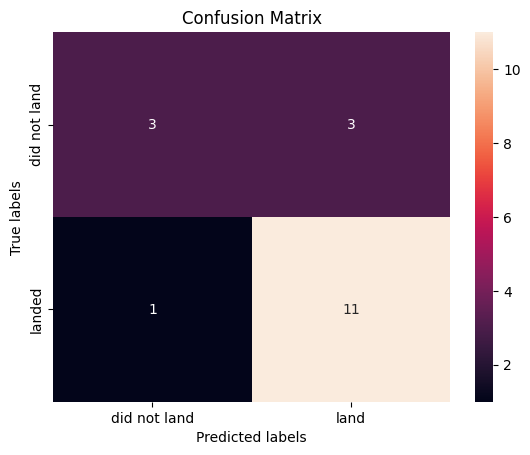

In [157]:
yhat_svm=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_svm)

In [158]:
#Classification report
report_svm=classification_report(Y_test, yhat_svm, target_names=["Class 0", "Class 1"])
print(report_svm)

              precision    recall  f1-score   support

     Class 0       0.75      0.50      0.60         6
     Class 1       0.79      0.92      0.85        12

    accuracy                           0.78        18
   macro avg       0.77      0.71      0.72        18
weighted avg       0.77      0.78      0.76        18



## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [159]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['log2', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier(random_state=2)

In [160]:
tree_cv=GridSearchCV(estimator=tree, param_grid=parameters, cv=cv, scoring="accuracy")
tree_cv.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=2, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=2),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['log2', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [161]:
print("tuned hyperparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hyperparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.888888888888889


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [162]:
accuracy_tree_test=tree_cv.score(X_test, Y_test)
accuracy_tree_test

0.7222222222222222

We can plot the confusion matrix


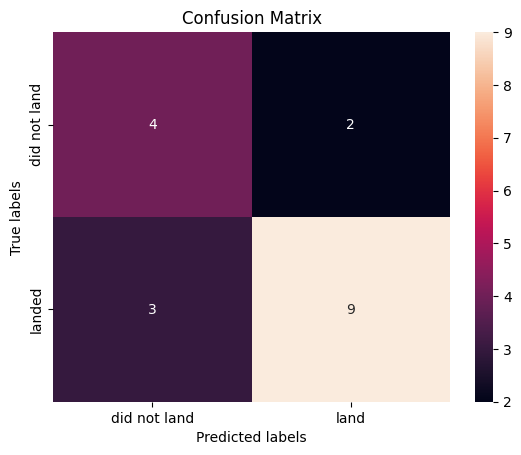

In [163]:
yhat_tree = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_tree)

In [164]:
#Classification report
report_tree=classification_report(Y_test, yhat_tree, target_names=["Class 0", "Class 1"])
print(report_tree)

              precision    recall  f1-score   support

     Class 0       0.57      0.67      0.62         6
     Class 1       0.82      0.75      0.78        12

    accuracy                           0.72        18
   macro avg       0.69      0.71      0.70        18
weighted avg       0.74      0.72      0.73        18



## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [165]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [166]:
knn_cv=GridSearchCV(estimator=KNN, param_grid=parameters, cv=cv, scoring="accuracy")
knn_cv.fit(X_train, Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=4, random_state=2, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]},
             scoring='accuracy')

In [167]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 8, 'p': 1}
accuracy : 0.861111111111111


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [168]:
accuracy_knn_test=knn_cv.score(X_test, Y_test)

In [169]:
accuracy_knn_test

0.8333333333333334

We can plot the confusion matrix


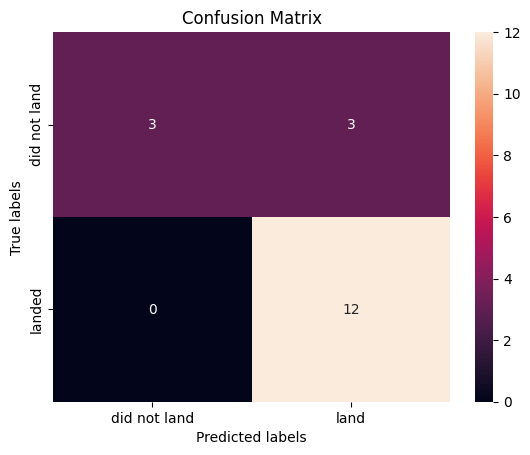

In [170]:
yhat_knn = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_knn)

In [171]:
#Classification report
report_knn=classification_report(Y_test, yhat_knn, target_names=["Class 0", "Class 1"])
print(report_knn)

              precision    recall  f1-score   support

     Class 0       1.00      0.50      0.67         6
     Class 1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



## TASK  12


Find the method performs best:


## evaluation
the models perfom all the same with an accuracy of 83,3 % on test data. 3 predictions are false positive.

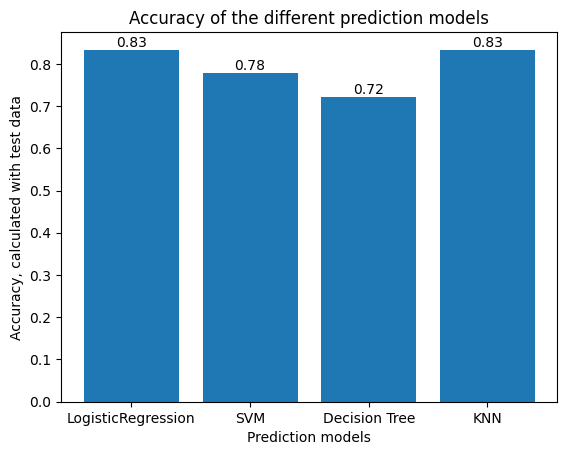

In [172]:
#build a bar chart to visualize the accuracy of the different models. 
x_accuracy=["LogisticRegression", "SVM", "Decision Tree", "KNN"]
y_accuracy= [accuracy_lg_test,accuracy_svm_test, accuracy_tree_test, accuracy_knn_test ]
bars= plt.bar(x_accuracy, y_accuracy)
# write the y value on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.xlabel("Prediction models")
plt.ylabel("Accuracy, calculated with test data")
plt.title("Accuracy of the different prediction models")
plt.show()

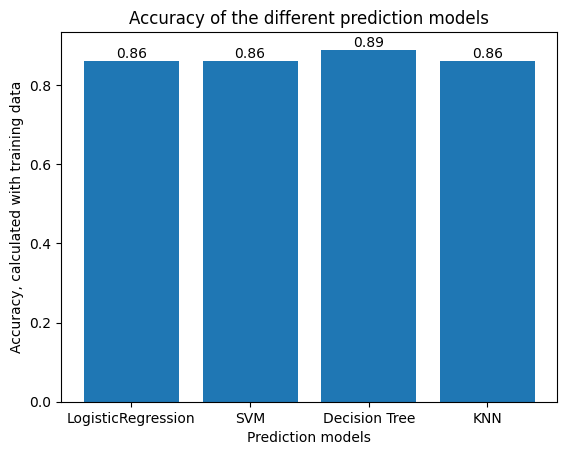

In [173]:
#Build the bar chart with accuracy calculated on training data. 
x_accuracy=["LogisticRegression", "SVM", "Decision Tree", "KNN"]
y_accuracy_train= [logreg_cv.best_score_,svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_ ]
bars=plt.bar(x_accuracy, y_accuracy_train)
# write the y value on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.xlabel("Prediction models")
plt.ylabel("Accuracy, calculated with training data")
plt.title("Accuracy of the different prediction models")
plt.show()

In [174]:
#Train the same analysis but standardize your data AFTER splitting train and test data. 
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

#split train and test
#X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.2, random_state=2)
#Stratify the data
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=2, stratify=Y)

transform = preprocessing.StandardScaler()
#standardize train data
X_train=transform.fit_transform(X_train)
# standardize test data
X_test=transform.transform(X_test)


tuned hyperparameters :(best parameters)  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.861111111111111
accuracy on test data 0.7777777777777778


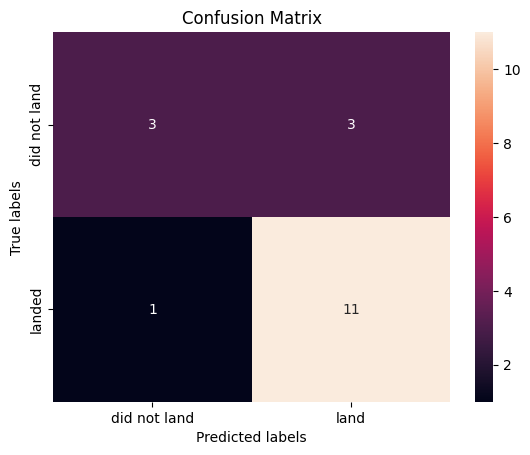

In [175]:
#logistic Regression
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression(random_state=2)
logreg_cv=GridSearchCV(estimator=lr, param_grid=parameters, cv=cv, scoring="accuracy")
logreg_cv.fit(X_train, Y_train)
best_parameters=logreg_cv.best_params_
print("tuned hyperparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)
accuracy_lg_test=logreg_cv.score(X_test, Y_test)
print("accuracy on test data", accuracy_lg_test)
yhat_log=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_log)


In [176]:
#Classification report
report_log=classification_report(Y_test, yhat_log, target_names=["Class 0", "Class 1"])
print(report_log)

              precision    recall  f1-score   support

     Class 0       0.75      0.50      0.60         6
     Class 1       0.79      0.92      0.85        12

    accuracy                           0.78        18
   macro avg       0.77      0.71      0.72        18
weighted avg       0.77      0.78      0.76        18



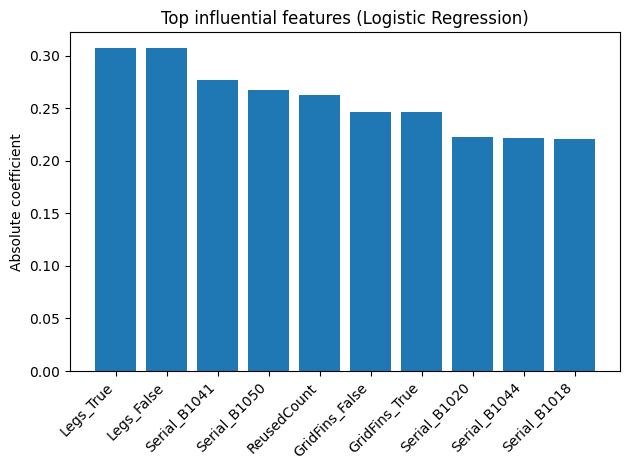

In [177]:
#understand the influence of the input variables

logreg_model = logreg_cv.best_estimator_
coef = logreg_model.coef_.ravel()

idx = np.argsort(np.abs(coef))[::-1][:10]

plt.bar(feature_names_X[idx], np.abs(coef)[idx])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Absolute coefficient")
plt.title("Top influential features (Logistic Regression)")
plt.tight_layout()
plt.show()


tuned hyperparameters :(best parameters)  {'C': 0.03162277660168379, 'gamma': 0.001, 'kernel': 'linear'}
accuracy : 0.861111111111111
accuracy on test data 0.7777777777777778


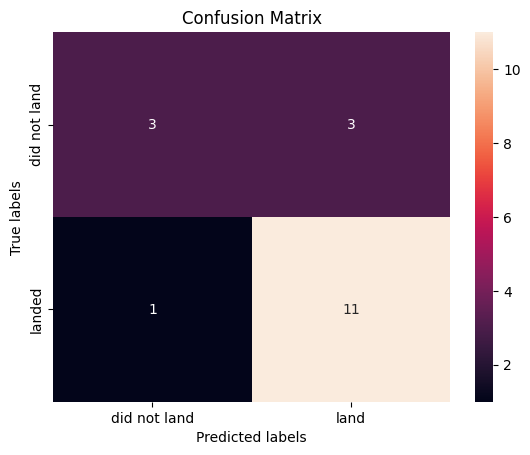

In [178]:
#svm
parameters = {'kernel':('linear', 'rbf','poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()
#changing the GridSearchCV definition
svm_cv = GridSearchCV(
    estimator=svm,
    param_grid=parameters,
    cv=cv,
    scoring="accuracy")

svm_cv.fit(X_train, Y_train)
print("tuned hyperparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)
accuracy_svm_test=svm_cv.score(X_test, Y_test)
print("accuracy on test data", accuracy_svm_test)
yhat_svm=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_svm)  

In [179]:
#Classification report
report_svm=classification_report(Y_test, yhat_svm, target_names=["Class 0", "Class 1"])
print(report_svm)

              precision    recall  f1-score   support

     Class 0       0.75      0.50      0.60         6
     Class 1       0.79      0.92      0.85        12

    accuracy                           0.78        18
   macro avg       0.77      0.71      0.72        18
weighted avg       0.77      0.78      0.76        18



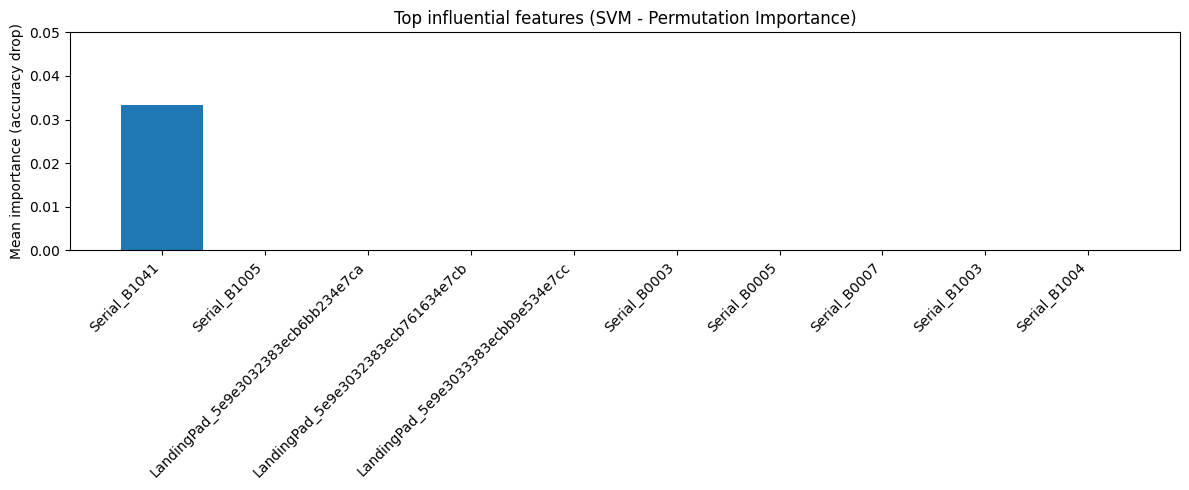

In [180]:
from sklearn.inspection import permutation_importance


svm_model = svm_cv.best_estimator_

result = permutation_importance(
    svm_model, X_test, Y_test,
    n_repeats=10, random_state=2, scoring="accuracy"
)

importances = -result.importances_mean
top_k = 10
idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(12,5))
plt.bar(feature_names_X[idx], importances[idx])
plt.xticks(rotation=45, ha="right")
plt.ylim(0, +0.05)
plt.ylabel("Mean importance (accuracy drop)")
plt.title("Top influential features (SVM - Permutation Importance)")
plt.tight_layout()
plt.show()

In [181]:
np.max(importances)

0.03333333333333334

In [182]:
print("X_test shape:", X_test.shape)
print("feature_names_X length:", len(feature_names_X))
print("importances length:", len(importances))

X_test shape: (18, 83)
feature_names_X length: 83
importances length: 83


In [183]:
print("Any NaNs in importances?", np.isnan(importances).any())
print("Min/Max importances:", np.min(importances), np.max(importances))

Any NaNs in importances? False
Min/Max importances: -0.0 0.03333333333333334


In [184]:
idx = np.argsort(importances)[::-1][:10]
print("Top 10 importances:", importances[idx])

Top 10 importances: [ 0.03333333 -0.         -0.         -0.         -0.         -0.
 -0.         -0.         -0.         -0.        ]


In [185]:
feature_names_X[idx]

Index(['Serial_B1041', 'Serial_B1005', 'LandingPad_5e9e3032383ecb6bb234e7ca',
       'LandingPad_5e9e3032383ecb761634e7cb',
       'LandingPad_5e9e3033383ecbb9e534e7cc', 'Serial_B0003', 'Serial_B0005',
       'Serial_B0007', 'Serial_B1003', 'Serial_B1004'],
      dtype='object')

In [186]:
importances[idx]

array([ 0.03333333, -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ])

In [187]:
importances

array([-0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
        0.03333333, -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.  

tuned hyperparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.888888888888889
accuracy on test data 0.7222222222222222


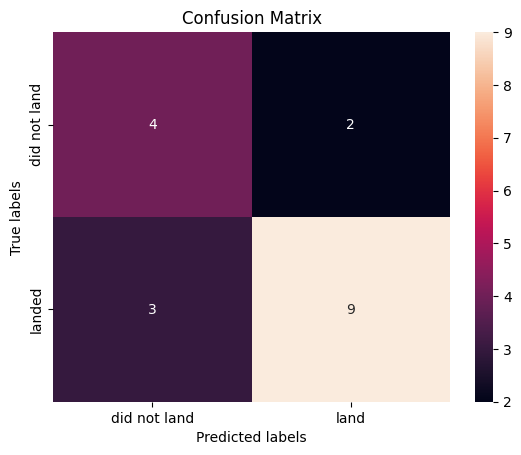

In [188]:
#decision tree
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['log2', 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}


tree = DecisionTreeClassifier(random_state=2)

tree_cv=GridSearchCV(estimator=tree, param_grid=parameters, cv=cv, scoring="accuracy")
tree_cv.fit(X_train, Y_train)

print("tuned hyperparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)
accuracy_tree_test=tree_cv.score(X_test, Y_test)
print("accuracy on test data", accuracy_tree_test)

yhat_tree = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_tree)

In [189]:
#Classification report
report_tree=classification_report(Y_test, yhat_tree, target_names=["Class 0", "Class 1"])
print(report_tree)

              precision    recall  f1-score   support

     Class 0       0.57      0.67      0.62         6
     Class 1       0.82      0.75      0.78        12

    accuracy                           0.72        18
   macro avg       0.69      0.71      0.70        18
weighted avg       0.74      0.72      0.73        18



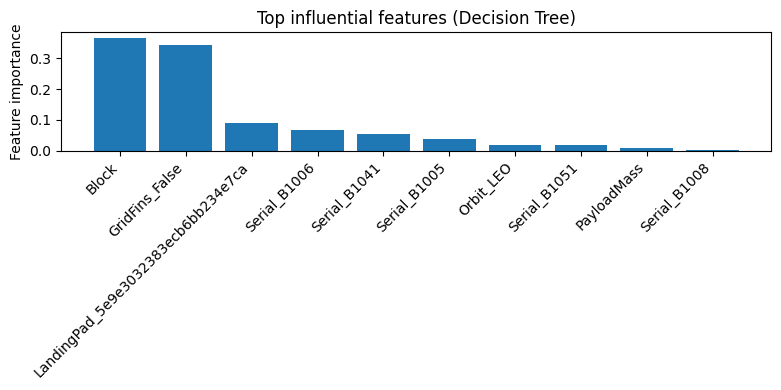

In [190]:
tree_model = tree_cv.best_estimator_
importances = tree_model.feature_importances_

top_k = 10
idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(8,4))
plt.bar(feature_names_X[idx], importances[idx])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Feature importance")
plt.title("Top influential features (Decision Tree)")
plt.tight_layout()
plt.show()

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 8, 'p': 1}
accuracy : 0.861111111111111
accuracy on test data 0.8333333333333334


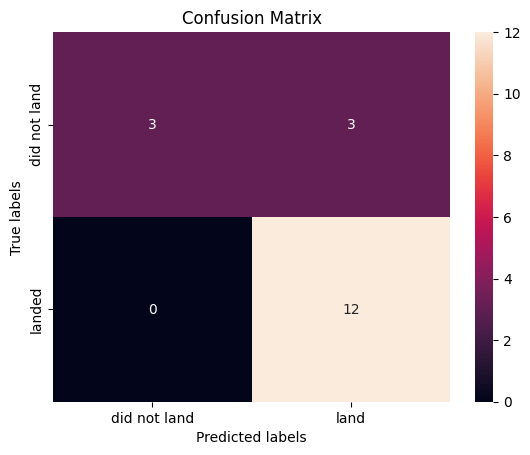

In [191]:
#KNN
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()
knn_cv=GridSearchCV(estimator=KNN, param_grid=parameters, cv=cv, scoring="accuracy")
knn_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)
accuracy_knn_test=knn_cv.score(X_test, Y_test)
print("accuracy on test data", accuracy_knn_test)
yhat_knn = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat_knn)

In [192]:
#Classification report
report_knn=classification_report(Y_test, yhat_knn, target_names=["Class 0", "Class 1"])
print(report_knn)

              precision    recall  f1-score   support

     Class 0       1.00      0.50      0.67         6
     Class 1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



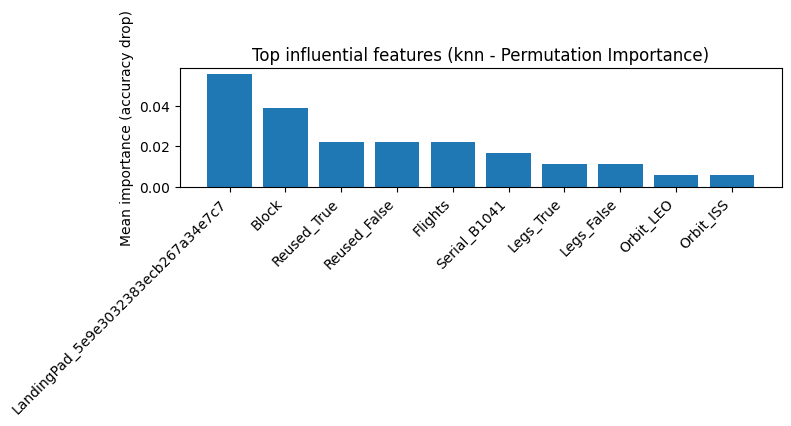

In [196]:
knn_model = knn_cv.best_estimator_

result = permutation_importance(
    knn_model, X_test, Y_test,
    n_repeats=10, random_state=2, scoring="accuracy"
)

importances = result.importances_mean
top_k = 10
idx = np.argsort(importances)[::-1][:top_k]

plt.figure(figsize=(8,4))
plt.bar(feature_names_X[idx], importances[idx])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean importance (accuracy drop)")
plt.title("Top influential features (knn - Permutation Importance)")
plt.tight_layout()
plt.show()

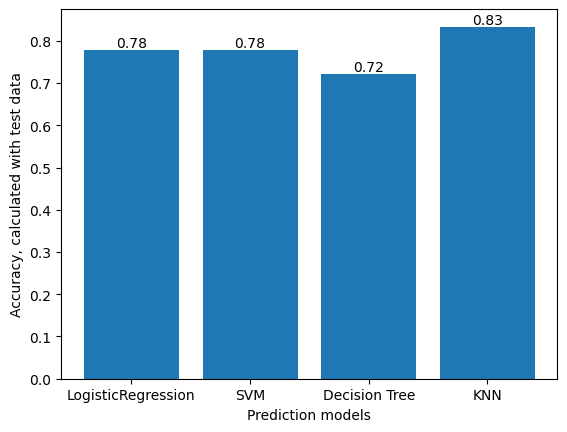

In [194]:
#build a bar chart to visualize the accuracy of the different models. 
x_accuracy=["LogisticRegression", "SVM", "Decision Tree", "KNN"]
y_accuracy= [accuracy_lg_test,accuracy_svm_test, accuracy_tree_test, accuracy_knn_test ]
bars= plt.bar(x_accuracy, y_accuracy)
# write the y value on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.xlabel("Prediction models")
plt.ylabel("Accuracy, calculated with test data")
plt.show()

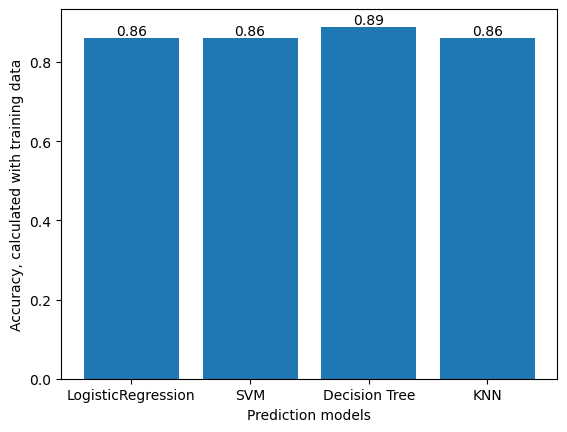

In [195]:
#Build the bar chart with accuracy calculated on training data. 
x_accuracy=["LogisticRegression", "SVM", "Decision Tree", "KNN"]
y_accuracy_train= [logreg_cv.best_score_,svm_cv.best_score_, tree_cv.best_score_, knn_cv.best_score_ ]
bars=plt.bar(x_accuracy, y_accuracy_train)
# write the y value on each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )
plt.xlabel("Prediction models")
plt.ylabel("Accuracy, calculated with training data")
plt.show()

## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
